[PDF report link](https://www.overleaf.com/read/bkbrwgnmgfqn#00d18e)\
[Streamlit application](https://fairface-app-dqnpzprmsxtvhydxzmcyjv.streamlit.app)

In [1]:
import ssl
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

import torchvision

# This contains all the tools needed to resize, crop, rotate, flip, and alter images.
# We will use it to normalize the CIFAR-10 images and convert them to PyTorch tensors.
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Subset

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1. Bypass SSL issue in some notebook environments
ssl._create_default_https_context = ssl._create_unverified_context

In [2]:
# Hyperparameters
batch_size = 200
learning_rate = 0.001
weight_decay = 1e-4
epochs = 50
validation_size = 5000
CHECK_POINT_PATH = "best_fairface_model.pt"

FairFace is a face image dataset which is race balanced. It contains 108,501 images from 7 different race groups: White, Black, Indian, East Asian, Southeast Asian, Middle Eastern, and Latino. Images were collected from the YFCC-100M Flickr dataset and labeled with race, gender, and age groups.

In [3]:
# ----------------------------
# Load dataset
# ----------------------------

import torch
from datasets import load_dataset, concatenate_datasets

# 1. Clear CUDA cache and load dataset
torch.cuda.empty_cache()

dataset = load_dataset(
    "HuggingFaceM4/FairFace",
    "0.25",
    cache_dir=".\dataset"
)

# 2. Combine train and validation into one single dataset pool
full_dataset = concatenate_datasets([dataset["train"], dataset["validation"]])

# 3. First Split: Pull out the 10% Test set (leaving 90% for Train + Val)
train_val_split = full_dataset.train_test_split(
    test_size=0.1, 
    stratify_by_column="age",
    seed=42
)

# 4. Second Split: Take that 90%, and split it into Train (80%) and Val (10% of total)
# Note: 0.1111 (or 1/9) of the remaining 90% is exactly equal to 10% of the original total.
final_train_val = train_val_split["train"].train_test_split(
    test_size=0.1111, 
    stratify_by_column="age",
    seed=42
)

# 5. Extract your final sets
train_ds = final_train_val["train"]
val_ds = final_train_val["test"]
test_ds = train_val_split["test"]

# Verify sizes
print(f"Final Train size:      {len(train_ds)} (~80%)")
print(f"Final Validation size: {len(val_ds)} (~10%)")
print(f"Final Test size:       {len(test_ds)} (~10%)")

ages = set(sample["age"] for sample in train_ds)

'[WinError 10054] An existing connection was forcibly closed by the remote host' thrown while requesting HEAD https://huggingface.co/datasets/HuggingFaceM4/FairFace/resolve/main/README.md
Retrying in 1s [Retry 1/5].
Using the latest cached version of the dataset since HuggingFaceM4/FairFace couldn't be found on the Hugging Face Hub
Found the latest cached dataset configuration '0.25' at dataset\HuggingFaceM4___fair_face\0.25\0.0.0\54d573cdb8b5af490ba8da9da2799628f6e5c496 (last modified on Sat Apr 18 12:56:35 2026).


Final Train size:      78159 (~80%)
Final Validation size: 9769 (~10%)
Final Test size:       9770 (~10%)


In [4]:
import os
from PIL import Image
import pandas as pd
from datasets import load_dataset

save_dir = "fairface_sample"
img_dir = os.path.join(save_dir, "images")
csv_path = os.path.join(save_dir, "labels.csv")

# ----------------------------
# SKIP IF ALREADY EXISTS
# ----------------------------
if os.path.exists(csv_path):
    print("Dataset already exists. Skipping download.")
else:
    os.makedirs(img_dir, exist_ok=True)

    dataset = load_dataset("HuggingFaceM4/FairFace", "0.25")
    samples = dataset["train"].select(range(10))

    data = []

    for i, sample in enumerate(samples):

        img = sample["image"]
        age = sample["age"]
        race = sample["race"]
        gender = sample["gender"]

        img_path = os.path.join(img_dir, f"img_{i}.jpg")
        img.save(img_path)

        data.append({
            "image": f"img_{i}.jpg",
            "age": age,
            "race": race,
            "gender": gender
        })

    df = pd.DataFrame(data)
    df.to_csv(csv_path, index=False)

    print("Dataset sample created successfully.")

Dataset already exists. Skipping download.


Data Fields
- image: The image
- age: Age class among ["0-2", "3-9", "10-19", "20-29", "30-39", "40-49", "50-59", "60-69", "more than 70"]
- gender: Gender class among ["Male", "Female"]
- race: Race class among ["East Asian", "Indian", "Black", "White", "Middle Eastern", "Latino_Hispanic", "Southeast Asian"]

In [5]:
print(
    open("MLModel.py", "r").read()
)

from torchvision import transforms

# CIFAR-10 normalization values
mean = (0.4914, 0.4822, 0.4465)             # RGB
std = (0.2470, 0.2435, 0.2616)

num_classes = 9

train_transform = transforms.Compose([
    transforms.RandomCrop(32,padding=4),    # add 4 pixel padding arround the picture and randomly crop for 32 pixel picture
                                            # this is done to randomly place the image at a random place to help prediction accurate
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),                  # values map to 0,1 from 0,256 to make train more stable
    transforms.Normalize(mean,std)
])

# validation/ test
eval_transform = transforms.Compose([
    transforms.Resize((32,32)),
    transforms.ToTensor(),                  
    transforms.Normalize(mean,std)
])

import torch.nn as nn

# CNN model
class CNN(nn.Module):

    def __init__(self, num_classes):
        super().__init__()

        # feature extractor using the original simple pattern

In [6]:
from MLModel import CNN, train_transform, eval_transform

def train_transform_fn(example):
    if isinstance(example["image"], list):
        example["image"] = [train_transform(img) for img in example["image"]]
    else:
        example["image"] = train_transform(example["image"])
    return example


def eval_transform_fn(example):
    if isinstance(example["image"], list):
        example["image"] = [eval_transform(img) for img in example["image"]]
    else:
        example["image"] = eval_transform(example["image"])
    return example

In [7]:
# # ----------------------------
# # Custom Dataset Wrapper
# # ----------------------------
# # 6. Train / validation set
# indices = torch.randperm(
#     len(train_ds),
#     generator=torch.Generator().manual_seed(42)
# ).tolist()

# val_indices = indices[:validation_size]
# train_indices = indices[validation_size:]

from sklearn.model_selection import StratifiedShuffleSplit
# ==========================================
# LABELS FOR STRATIFICATION
# ==========================================
labels = train_ds["age"]

# ==========================================
# STRATIFIED SPLIT
# ==========================================
splitter = StratifiedShuffleSplit(
    n_splits=1,
    test_size=validation_size,
    random_state=42
)

train_indices, val_indices = next(
    splitter.split(
        X=range(len(labels)),
        y=labels
    )
)

train_dataset = train_ds.select(train_indices)
train_dataset.set_transform(train_transform_fn)

val_dataset = train_ds.select(val_indices)
val_dataset.set_transform(eval_transform_fn)

test_dataset = test_ds
test_dataset.set_transform(eval_transform_fn)

train_dataset = DataLoader(train_dataset,batch_size=batch_size,shuffle=True)
val_dataset = DataLoader(val_dataset,batch_size=batch_size,shuffle=False)
test_dataset = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [8]:
num_classes = len(ages)
print("number of data classes in the dataset = ",num_classes)


model = CNN(len(ages)).to(device)

number of data classes in the dataset =  9


In [9]:
criterion = nn.CrossEntropyLoss()
optimiser = optim.AdamW(model.parameters(),lr=learning_rate,weight_decay=weight_decay)

In [10]:
def evaluate(model, data_loader):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for batch in data_loader:
            images = batch["image"]
            labels = batch["age"]

            if not isinstance(labels, torch.Tensor):
                labels = torch.tensor(labels)

            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            predictions = outputs.argmax(dim=1)
            total += labels.size(0)
            correct += (predictions == labels).sum().item()

    epoch_loss = running_loss / len(data_loader.dataset)
    epoch_accuracy = 100 * correct / total
    return epoch_loss, epoch_accuracy

In [11]:
import os
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

In [12]:
def safe_batch(batch):
    images = batch["image"]
    labels = batch["age"]

    # Convert safely
    if not isinstance(images, torch.Tensor):
        images = torch.stack(images)

    if not isinstance(labels, torch.Tensor):
        labels = torch.tensor(labels)

    # Move to device
    images = images.to(device, dtype=torch.float32)
    labels = labels.to(device).long()

    # HARD CHECK (prevents CUDA poisoning)
    if labels.min() < 0 or labels.max() >= len(ages):
        raise ValueError(f"Invalid labels detected: {labels.min()} - {labels.max()}")

    return images, labels

In [13]:
# List for monitoring
train_validation_losses = {
    "train_loss" : [],
    "validation_loss" : []
}
train_validation_accuracies = {
    "train_accuracies" : [],
    "validation_accuracies" : []
}
best_value_accuracy = 0.0

In [14]:
def trainTheModel():
    global best_value_accuracy

    for epoch in range(epochs):
        model.train()

        running_training_loss = 0.0
        train_correct = 0
        train_total = 0

        for batch in train_dataset:

            try:
                # =========================
                # SAFE BATCH PROCESSING
                # =========================
                images, labels = safe_batch(batch)

                # =========================
                # FORWARD PASS
                # =========================
                optimiser.zero_grad()

                outputs = model(images)
                loss = criterion(outputs, labels)

                # =========================
                # BACKWARD PASS
                # =========================
                loss.backward()
                optimiser.step()

                # =========================
                # METRICS
                # =========================
                running_training_loss += loss.item() * images.size(0)

                predictions = outputs.argmax(dim=1)

                train_total += labels.size(0)
                train_correct += (predictions == labels).sum().item()

            except Exception as e:
                print("⚠️ Skipping bad batch:", e)
                continue

        # =========================
        # EPOCH METRICS
        # =========================
        epoch_train_loss = running_training_loss / len(train_dataset.dataset)
        epoch_train_accuracy = 100 * train_correct / train_total

        epoch_val_loss, epoch_val_accuracy = evaluate(model, val_dataset)

        train_validation_losses["train_loss"].append(epoch_train_loss)
        train_validation_accuracies["train_accuracies"].append(epoch_train_accuracy)
        train_validation_losses["validation_loss"].append(epoch_val_loss)
        train_validation_accuracies["validation_accuracies"].append(epoch_val_accuracy)

        print(
            f"Epoch [{epoch+1}/{epochs}] | "
            f"Train Loss: {epoch_train_loss:.4f} | "
            f"Train Accuracy: {epoch_train_accuracy:.2f}% | "
            f"Val Loss: {epoch_val_loss:.4f} | "
            f"Val Accuracy: {epoch_val_accuracy:.2f}%"
        )

        # =========================
        # CHECKPOINTING
        # =========================
        if epoch_val_accuracy > best_value_accuracy:
            best_value_accuracy = epoch_val_accuracy

            torch.save(
                {
                    "epoch": epoch + 1,
                    "model_state_dict": model.state_dict(),
                    "optimizer_state_dict": optimiser.state_dict(),
                    "val_accuracy": epoch_val_accuracy,
                    "val_loss": epoch_val_loss,
                },
                CHECK_POINT_PATH,
            )

            print(f"🏆 Best model saved at epoch {epoch+1}\n")

trainTheModel()

Epoch [1/50] | Train Loss: 1.8741 | Train Accuracy: 29.41% | Val Loss: 1.8674 | Val Accuracy: 29.58%
🏆 Best model saved at epoch 1

Epoch [2/50] | Train Loss: 1.8672 | Train Accuracy: 29.57% | Val Loss: 1.8612 | Val Accuracy: 29.58%
Epoch [3/50] | Train Loss: 1.8660 | Train Accuracy: 29.58% | Val Loss: 1.8608 | Val Accuracy: 29.58%
Epoch [4/50] | Train Loss: 1.8647 | Train Accuracy: 29.57% | Val Loss: 1.8509 | Val Accuracy: 29.58%
Epoch [5/50] | Train Loss: 1.8628 | Train Accuracy: 29.58% | Val Loss: 1.8514 | Val Accuracy: 29.58%
Epoch [6/50] | Train Loss: 1.8622 | Train Accuracy: 29.58% | Val Loss: 1.8511 | Val Accuracy: 29.58%
Epoch [7/50] | Train Loss: 1.8611 | Train Accuracy: 29.59% | Val Loss: 1.8570 | Val Accuracy: 29.58%
Epoch [8/50] | Train Loss: 1.8596 | Train Accuracy: 29.58% | Val Loss: 1.8446 | Val Accuracy: 29.62%
🏆 Best model saved at epoch 8

Epoch [9/50] | Train Loss: 1.8584 | Train Accuracy: 29.59% | Val Loss: 1.8464 | Val Accuracy: 29.64%
🏆 Best model saved at epoch 9

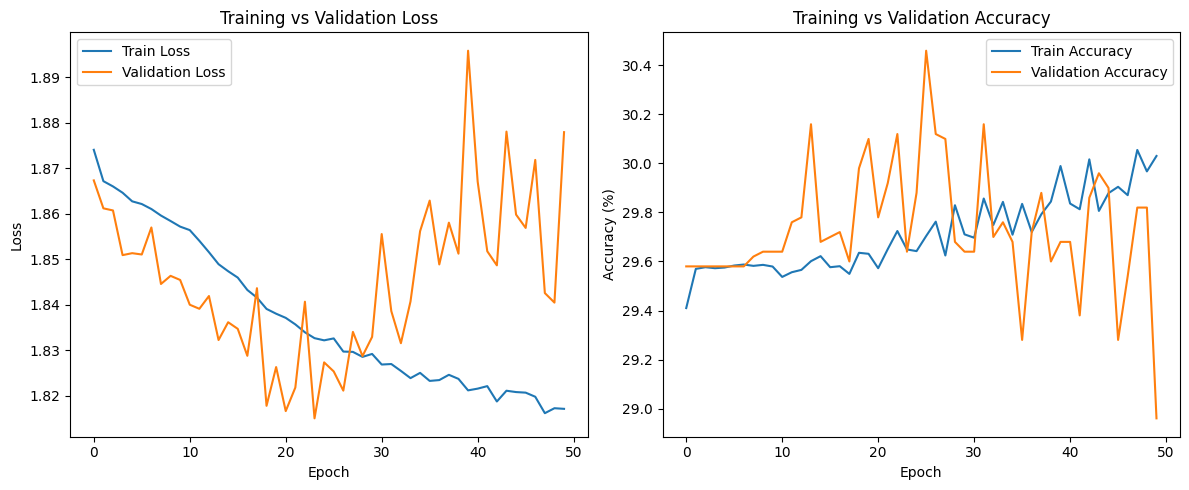

In [15]:
# 12. Plot graphs
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_validation_losses["train_loss"], label="Train Loss")
plt.plot(train_validation_losses["validation_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_validation_accuracies["train_accuracies"], label="Train Accuracy")
plt.plot(train_validation_accuracies["validation_accuracies"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Training vs Validation Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

In [16]:
from sklearn.metrics import confusion_matrix, classification_report, f1_score, accuracy_score
import numpy as np

In [17]:
def full_evaluate(model, data_loader):
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in data_loader:

            images = batch["image"].to(device)
            labels = batch["age"].to(device)

            outputs = model(images)
            preds = outputs.argmax(dim=1)

            all_preds.append(preds.cpu().numpy())
            all_labels.append(labels.cpu().numpy())

    # flatten
    all_preds = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)

    # metrics
    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average="weighted")
    cm = confusion_matrix(all_labels, all_preds)

    report = classification_report(all_labels, all_preds)

    return acc, f1, cm, report

In [18]:
model = CNN(num_classes).to(device)
checkpoint = torch.load(
    CHECK_POINT_PATH,
    map_location=device
)
model.load_state_dict(checkpoint["model_state_dict"])

<All keys matched successfully>

In [19]:
acc, f1, cm, report = full_evaluate(model, val_dataset)

print("Accuracy:", acc)
print("F1 Score:", f1)
print("\nClassification Report:\n", report)

Accuracy: 0.3046
F1 Score: 0.19490686126449686

Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00       102
           1       0.23      0.09      0.13       602
           2       0.00      0.00      0.00       526
           3       0.32      0.89      0.47      1479
           4       0.25      0.13      0.18      1104
           5       0.00      0.00      0.00       619
           6       0.29      0.02      0.04       360
           7       0.00      0.00      0.00       159
           8       0.00      0.00      0.00        49

    accuracy                           0.30      5000
   macro avg       0.12      0.13      0.09      5000
weighted avg       0.20      0.30      0.19      5000



d:\IJSE CAME\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\IJSE CAME\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\IJSE CAME\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


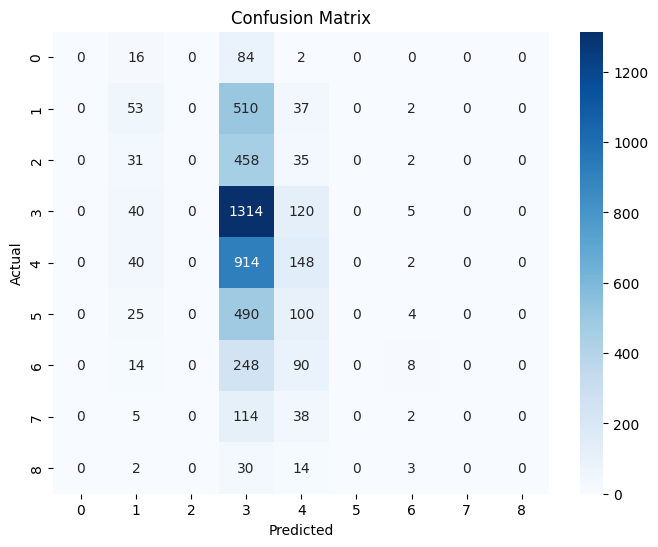

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

As the accuracy is based on how the data is distributed it is good to check which has great data distribution. So, it is best to have classification for classwise and bias for high accuracy class

In [21]:
def plotGraphsClasswise(age_acc, race_acc, gender_acc):
    import matplotlib.pyplot as plt

    # ==========================================
    # AGE ACCURACY PLOT
    # ==========================================
    plt.figure(figsize=(10, 5))

    plt.bar(
        [str(k) for k in age_acc.keys()],
        list(age_acc.values())
    )

    plt.xlabel("Age Class")
    plt.ylabel("Accuracy")
    plt.title("Age-wise Accuracy")
    plt.ylim(0, 1)
    plt.grid(True)

    plt.show()

    # ==========================================
    # RACE ACCURACY PLOT
    # ==========================================
    plt.figure(figsize=(10, 5))

    plt.bar(
        list(race_acc.keys()),
        list(race_acc.values())
    )

    plt.xlabel("Race Group")
    plt.ylabel("Accuracy")
    plt.title("Race-wise Accuracy")

    plt.xticks(rotation=20)
    plt.ylim(0, 1)
    plt.grid(True)

    plt.show()

    # ==========================================
    # GENDER ACCURACY PLOT
    # ==========================================
    plt.figure(figsize=(6, 5))

    plt.bar(
        list(gender_acc.keys()),
        list(gender_acc.values())
    )

    plt.xlabel("Gender")
    plt.ylabel("Accuracy")
    plt.title("Gender-wise Accuracy")
    plt.ylim(0, 1)
    plt.grid(True)

    plt.show()

In [22]:
def classWiseEvaluation(model, data_loader, device, num_age_classes=9):

    import torch
    model.eval()

    # ==========================================
    # CLASS LABEL MAPS
    # ==========================================
    race_classes = {
        0: "White",
        1: "Black",
        2: "Latino_Hispanic",
        3: "East Asian",
        4: "Southeast Asian",
        5: "Indian",
        6: "Middle Eastern"
    }

    gender_classes = {
        0: "Male",
        1: "Female"
    }

    # ==========================================
    # STORAGE
    # ==========================================
    race_correct = {
        race_classes[k]: 0
        for k in race_classes
    }

    race_total = {
        race_classes[k]: 0
        for k in race_classes
    }

    gender_correct = {
        gender_classes[k]: 0
        for k in gender_classes
    }

    gender_total = {
        gender_classes[k]: 0
        for k in gender_classes
    }

    age_correct = {
        i: 0
        for i in range(num_age_classes)
    }

    age_total = {
        i: 0
        for i in range(num_age_classes)
    }

    # ==========================================
    # EVALUATION LOOP
    # ==========================================
    with torch.no_grad():

        for batch in data_loader:
            images = batch["image"].to(device)
            labels = batch["age"].to(device)
            races = batch["race"]
            genders = batch["gender"]
        
            outputs = model(images)
            preds = outputs.argmax(dim=1)

            for i in range(len(labels)):

                # ==========================================
                # EXTRACT LABELS
                # ==========================================
                age = labels[i].item()
                race_id = int(races[i])
                gender_id = int(genders[i])
                race = race_classes[race_id]
                gender = gender_classes[gender_id]

                correct = (
                    preds[i] == labels[i]
                ).item()

                # ==========================================
                # AGE
                # ==========================================
                age_total[age] += 1
                age_correct[age] += correct

                # ==========================================
                # RACE
                # ==========================================
                race_total[race] += 1
                race_correct[race] += correct

                # ==========================================
                # GENDER
                # ==========================================
                gender_total[gender] += 1
                gender_correct[gender] += correct

    # ==========================================
    # SAFE ACCURACY CALCULATION
    # ==========================================
    age_acc = {
        k: (
            age_correct[k] / age_total[k] if age_total[k] > 0 else 0
        )
        for k in age_total
    }

    race_acc = {
        k: (
            race_correct[k] / race_total[k] if race_total[k] > 0 else 0
        )
        for k in race_total
    }

    gender_acc = {
        k: (
            gender_correct[k] / gender_total[k] if gender_total[k] > 0 else 0
        )
        for k in gender_total
    }

    # ==========================================
    # FAIRNESS GAPS
    # ==========================================
    fairness_gap_race = (
        max(race_acc.values()) -
        min(race_acc.values())
    )

    fairness_gap_gender = (
        max(gender_acc.values()) -
        min(gender_acc.values())
    )

    fairness_gap_age = (
        max(age_acc.values()) -
        min(age_acc.values())
    )

    # ==========================================
    # PRINT RESULTS
    # ==========================================
    print("\n===================================")
    print(" FAIRNESS ANALYSIS ")
    print("===================================")

    # ==========================================
    # AGE RESULTS
    # ==========================================
    print("\nAGE ACCURACY")

    for k, v in age_acc.items():
        print(f"Age {k}: {v:.3f}")

    # ==========================================
    # RACE RESULTS
    # ==========================================
    print("\nRACE ACCURACY")

    for k, v in race_acc.items():
        print(f"{k}: {v:.3f}")

    # ==========================================
    # GENDER RESULTS
    # ==========================================
    print("\nGENDER ACCURACY")

    for k, v in gender_acc.items():
        print(f"{k}: {v:.3f}")

    plotGraphsClasswise(age_acc,race_acc,gender_acc)
    # ==========================================
    # FAIRNESS GAPS
    # ==========================================
    print("\nFAIRNESS GAPS")

    print(
        f"Race Gap   : {fairness_gap_race:.3f}"
    )

    print(
        f"Gender Gap : {fairness_gap_gender:.3f}"
    )

    print(
        f"Age Gap    : {fairness_gap_age:.3f}"
    )

    # ==========================================
    # RETURN EVERYTHING
    # ==========================================
    return {
        "age_acc": age_acc,
        "race_acc": race_acc,
        "gender_acc": gender_acc,
        "fairness_gap_age": fairness_gap_age,
        "fairness_gap_race": fairness_gap_race,
        "fairness_gap_gender": fairness_gap_gender
    }


 FAIRNESS ANALYSIS 

AGE ACCURACY
Age 0: 0.000
Age 1: 0.088
Age 2: 0.000
Age 3: 0.888
Age 4: 0.134
Age 5: 0.000
Age 6: 0.022
Age 7: 0.000
Age 8: 0.000

RACE ACCURACY
White: 0.398
Black: 0.267
Latino_Hispanic: 0.266
East Asian: 0.318
Southeast Asian: 0.258
Indian: 0.267
Middle Eastern: 0.343

GENDER ACCURACY
Male: 0.257
Female: 0.358


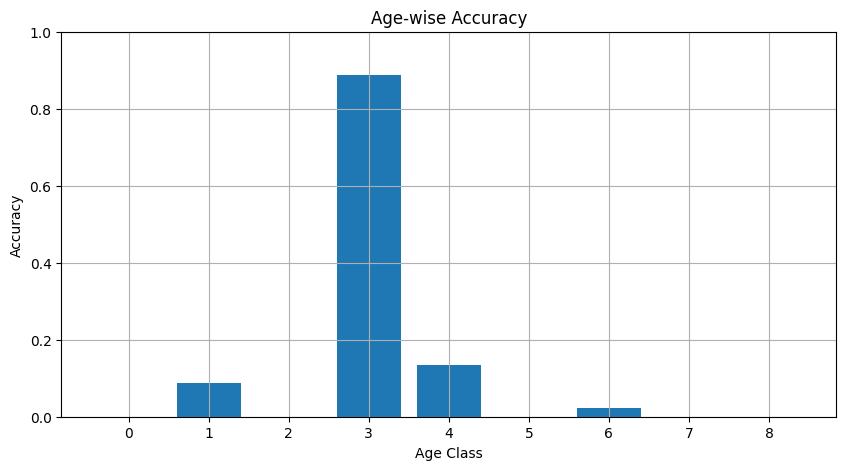

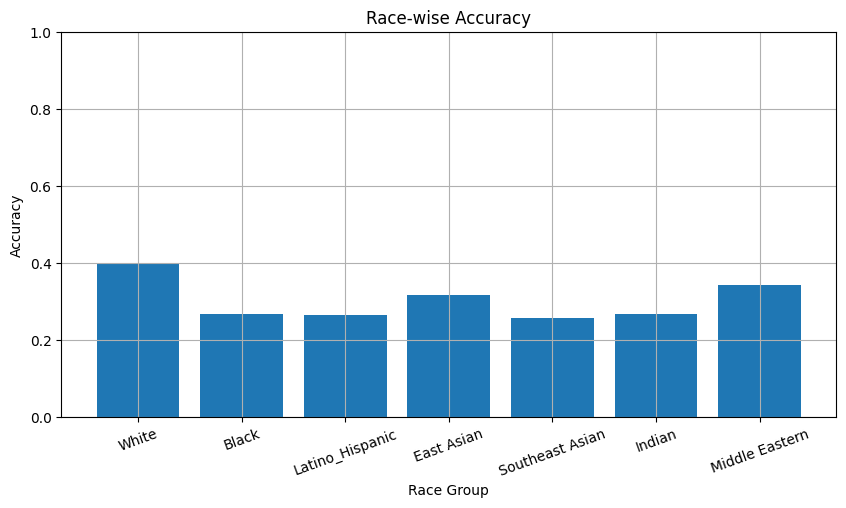

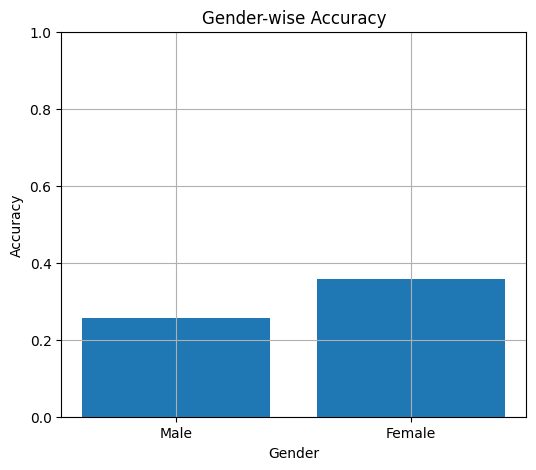


FAIRNESS GAPS
Race Gap   : 0.140
Gender Gap : 0.101
Age Gap    : 0.888


In [23]:
fairness = classWiseEvaluation(model, val_dataset, device)

race_acc = fairness["race_acc"]
gender_acc = fairness["gender_acc"]
age_acc = fairness["age_acc"]

In [24]:
def build_class_weights_gap(age_acc, num_classes=9, device="cpu"):
    import torch

    weights = torch.zeros(num_classes)
    max_acc = max(age_acc.values())

    for cls in range(num_classes):
        # gap = max_acc - age_acc.get(cls, 0)
        gap = age_acc.get(cls, 0)
        weights[cls] = 1/(gap + 1e-3)

    weights = weights / weights.sum() * num_classes
    return weights.to(device)

In [25]:
import torch
from torch.utils.data import WeightedRandomSampler
from collections import Counter

def build_class_weights_gap(dataset, age_acc, device="cpu"):
    """
    Computes sample weights combining stratification (inverse frequency of age groups)
    and accuracy gaps (sampling low-accuracy groups more often).
    """
    # 1. Stratification Component: Calculate total inverse frequency for age
    ages = dataset["age"]
    age_counts = Counter(ages)
    total_samples = len(ages)
    
    # 2. Performance Gap Component
    max_age_acc = max(age_acc.values()) if age_acc else 1.0

    weights = []
    for age in ages:
        # Stratification weight (smaller classes get a boost to balance distribution)
        strat_weight = total_samples / (len(age_counts) * age_counts[age])
        
        # Accuracy gap weight (low performing classes get a boost)
        age_gap = max_age_acc - age_acc.get(age, max_age_acc)
        gap_weight = age_gap + 1e-3
        
        # Combine both strategies multiplicatively
        combined_weight = strat_weight * gap_weight
        weights.append(combined_weight)

    # Return tensor mapped to your working device
    return torch.tensor(weights, dtype=torch.float, device=device)

# --- Usage Implementation ---

# 1. Generate the combined stratification + gap weights
sample_weights = build_class_weights_gap(
    dataset=train_ds,  # Your training HuggingFace dataset
    age_acc=age_acc,   # Dictionary of current age accuracies
    device=device
)

# 2. Feed weights into the WeightedRandomSampler
# Note: WeightedRandomSampler weights MUST be on CPU when initialized
sampler = WeightedRandomSampler(
    weights=sample_weights.cpu(), 
    num_samples=len(sample_weights),
    replacement=True
)

In [26]:
train_loader = DataLoader(
    train_dataset.dataset,
    batch_size=batch_size,
    sampler=sampler
)

train_validation_losses = {
    "train_loss" : [],
    "validation_loss" : []
}
train_validation_accuracies = {
    "train_accuracies" : [],
    "validation_accuracies" : []
}
best_value_accuracy = 0.0

trainTheModel()

Epoch [1/50] | Train Loss: 1.8338 | Train Accuracy: 29.58% | Val Loss: 1.8254 | Val Accuracy: 30.46%
🏆 Best model saved at epoch 1

Epoch [2/50] | Train Loss: 1.8332 | Train Accuracy: 29.65% | Val Loss: 1.8254 | Val Accuracy: 30.46%
Epoch [3/50] | Train Loss: 1.8349 | Train Accuracy: 29.60% | Val Loss: 1.8254 | Val Accuracy: 30.46%
Epoch [4/50] | Train Loss: 1.8330 | Train Accuracy: 29.71% | Val Loss: 1.8254 | Val Accuracy: 30.46%
Epoch [5/50] | Train Loss: 1.8339 | Train Accuracy: 29.74% | Val Loss: 1.8254 | Val Accuracy: 30.46%
Epoch [6/50] | Train Loss: 1.8321 | Train Accuracy: 29.61% | Val Loss: 1.8254 | Val Accuracy: 30.46%
Epoch [7/50] | Train Loss: 1.8320 | Train Accuracy: 29.64% | Val Loss: 1.8254 | Val Accuracy: 30.46%
Epoch [8/50] | Train Loss: 1.8332 | Train Accuracy: 29.73% | Val Loss: 1.8254 | Val Accuracy: 30.46%
Epoch [9/50] | Train Loss: 1.8332 | Train Accuracy: 29.54% | Val Loss: 1.8254 | Val Accuracy: 30.46%
Epoch [10/50] | Train Loss: 1.8331 | Train Accuracy: 29.54% 

In [27]:
model = CNN(num_classes).to(device)
checkpoint = torch.load(
    CHECK_POINT_PATH,
    map_location=device
)
model.load_state_dict(checkpoint["model_state_dict"])

acc, f1, cm, report = full_evaluate(model, val_dataset)

print("Accuracy:", acc)
print("F1 Score:", f1)
print("\nClassification Report:\n", report)

Accuracy: 0.3046
F1 Score: 0.19490686126449686

Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00       102
           1       0.23      0.09      0.13       602
           2       0.00      0.00      0.00       526
           3       0.32      0.89      0.47      1479
           4       0.25      0.13      0.18      1104
           5       0.00      0.00      0.00       619
           6       0.29      0.02      0.04       360
           7       0.00      0.00      0.00       159
           8       0.00      0.00      0.00        49

    accuracy                           0.30      5000
   macro avg       0.12      0.13      0.09      5000
weighted avg       0.20      0.30      0.19      5000



d:\IJSE CAME\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\IJSE CAME\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\IJSE CAME\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


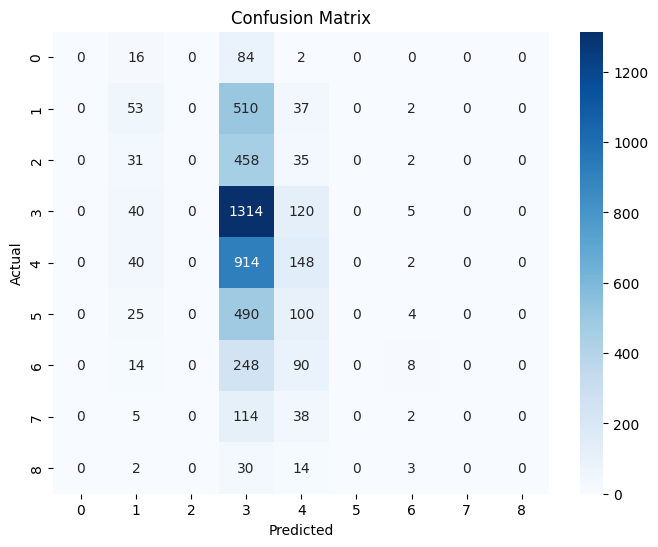

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


 FAIRNESS ANALYSIS 

AGE ACCURACY
Age 0: 0.000
Age 1: 0.088
Age 2: 0.000
Age 3: 0.888
Age 4: 0.134
Age 5: 0.000
Age 6: 0.022
Age 7: 0.000
Age 8: 0.000

RACE ACCURACY
White: 0.398
Black: 0.267
Latino_Hispanic: 0.266
East Asian: 0.318
Southeast Asian: 0.258
Indian: 0.267
Middle Eastern: 0.343

GENDER ACCURACY
Male: 0.257
Female: 0.358


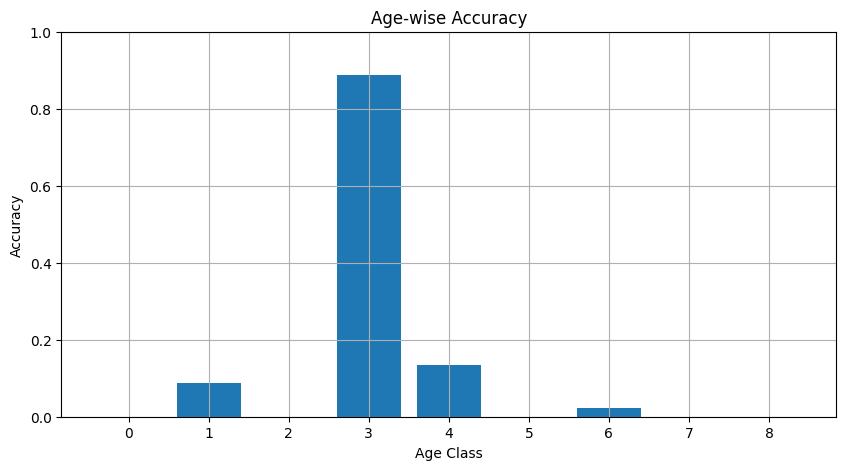

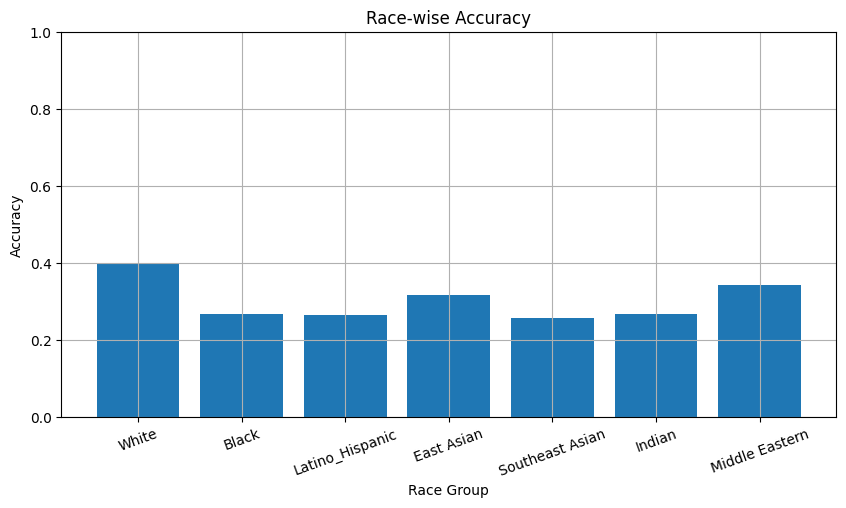

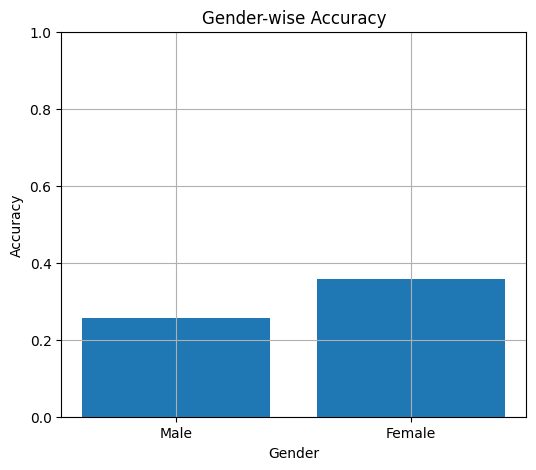


FAIRNESS GAPS
Race Gap   : 0.140
Gender Gap : 0.101
Age Gap    : 0.888


In [29]:
fairness = classWiseEvaluation(model, val_dataset, device)

race_acc = fairness["race_acc"]
gender_acc = fairness["gender_acc"]
age_acc = fairness["age_acc"]

If the batch size is low it causes for wrong predictions dueto less pattern identification and if high the weights aligned such that it has memorised output so  to achieve best prediction the batch size is used as a hyperparameter.

The system was trained for batch size of :  50
Epoch [1/200] | Train Loss: 1.8339 | Train Accuracy: 29.69% | Val Loss: 1.8254 | Val Accuracy: 30.46%
🏆 Best model saved at epoch 1

Epoch [2/200] | Train Loss: 1.8327 | Train Accuracy: 29.71% | Val Loss: 1.8254 | Val Accuracy: 30.46%
Epoch [3/200] | Train Loss: 1.8339 | Train Accuracy: 29.60% | Val Loss: 1.8254 | Val Accuracy: 30.46%
Epoch [4/200] | Train Loss: 1.8328 | Train Accuracy: 29.47% | Val Loss: 1.8254 | Val Accuracy: 30.46%
Epoch [5/200] | Train Loss: 1.8317 | Train Accuracy: 29.77% | Val Loss: 1.8254 | Val Accuracy: 30.46%
Epoch [6/200] | Train Loss: 1.8333 | Train Accuracy: 29.65% | Val Loss: 1.8254 | Val Accuracy: 30.46%
Epoch [7/200] | Train Loss: 1.8336 | Train Accuracy: 29.63% | Val Loss: 1.8254 | Val Accuracy: 30.46%
Epoch [8/200] | Train Loss: 1.8328 | Train Accuracy: 29.60% | Val Loss: 1.8254 | Val Accuracy: 30.46%
Epoch [9/200] | Train Loss: 1.8325 | Train Accuracy: 29.68% | Val Loss: 1.8254 | Val Accuracy: 30.46%
Epoc

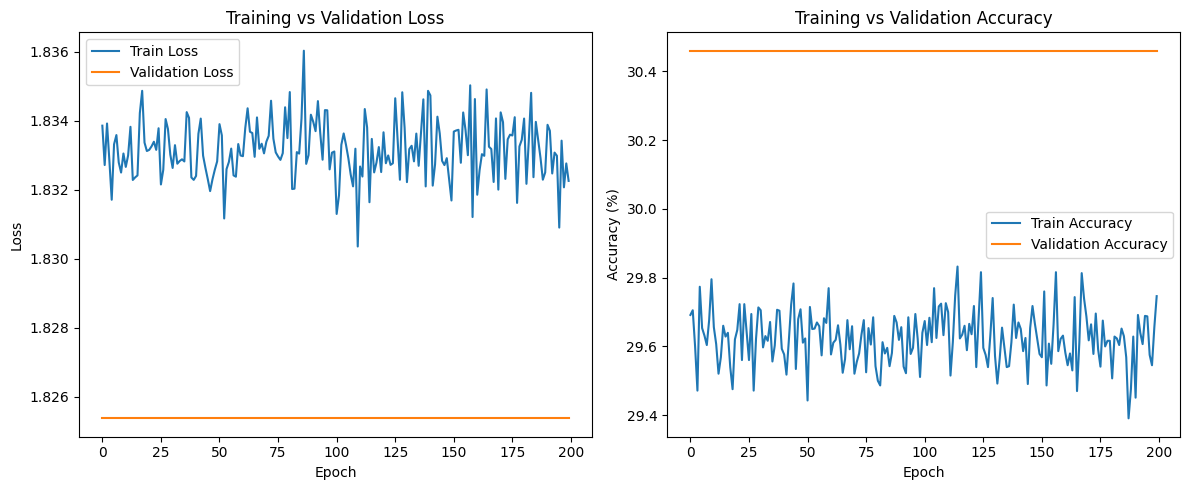

The system was trained for batch size of :  100
Epoch [1/200] | Train Loss: 1.8346 | Train Accuracy: 29.48% | Val Loss: 1.8254 | Val Accuracy: 30.46%
Epoch [2/200] | Train Loss: 1.8346 | Train Accuracy: 29.59% | Val Loss: 1.8254 | Val Accuracy: 30.46%
Epoch [3/200] | Train Loss: 1.8341 | Train Accuracy: 29.70% | Val Loss: 1.8254 | Val Accuracy: 30.46%
Epoch [4/200] | Train Loss: 1.8334 | Train Accuracy: 29.56% | Val Loss: 1.8254 | Val Accuracy: 30.46%
Epoch [5/200] | Train Loss: 1.8313 | Train Accuracy: 29.73% | Val Loss: 1.8254 | Val Accuracy: 30.46%
Epoch [6/200] | Train Loss: 1.8328 | Train Accuracy: 29.62% | Val Loss: 1.8254 | Val Accuracy: 30.46%
Epoch [7/200] | Train Loss: 1.8329 | Train Accuracy: 29.64% | Val Loss: 1.8254 | Val Accuracy: 30.46%
Epoch [8/200] | Train Loss: 1.8327 | Train Accuracy: 29.55% | Val Loss: 1.8254 | Val Accuracy: 30.46%
Epoch [9/200] | Train Loss: 1.8333 | Train Accuracy: 29.64% | Val Loss: 1.8254 | Val Accuracy: 30.46%
Epoch [10/200] | Train Loss: 1.833

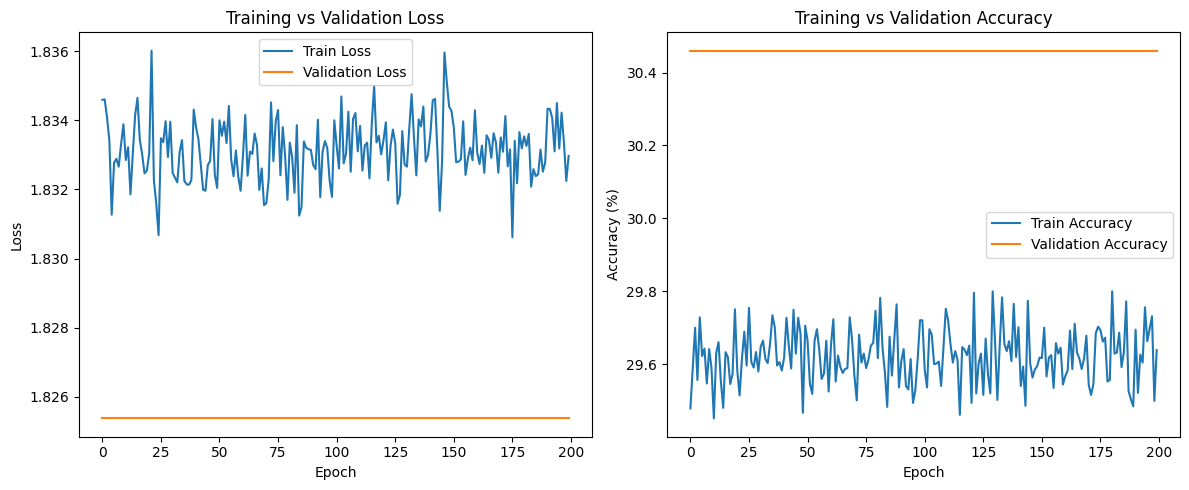

The system was trained for batch size of :  150
Epoch [1/200] | Train Loss: 1.8330 | Train Accuracy: 29.49% | Val Loss: 1.8254 | Val Accuracy: 30.46%
Epoch [2/200] | Train Loss: 1.8315 | Train Accuracy: 29.74% | Val Loss: 1.8254 | Val Accuracy: 30.46%
Epoch [3/200] | Train Loss: 1.8316 | Train Accuracy: 29.79% | Val Loss: 1.8254 | Val Accuracy: 30.46%
Epoch [4/200] | Train Loss: 1.8333 | Train Accuracy: 29.75% | Val Loss: 1.8254 | Val Accuracy: 30.46%
Epoch [5/200] | Train Loss: 1.8327 | Train Accuracy: 29.59% | Val Loss: 1.8254 | Val Accuracy: 30.46%
Epoch [6/200] | Train Loss: 1.8328 | Train Accuracy: 29.71% | Val Loss: 1.8254 | Val Accuracy: 30.46%
Epoch [7/200] | Train Loss: 1.8339 | Train Accuracy: 29.65% | Val Loss: 1.8254 | Val Accuracy: 30.46%
Epoch [8/200] | Train Loss: 1.8349 | Train Accuracy: 29.49% | Val Loss: 1.8254 | Val Accuracy: 30.46%
Epoch [9/200] | Train Loss: 1.8320 | Train Accuracy: 29.68% | Val Loss: 1.8254 | Val Accuracy: 30.46%
Epoch [10/200] | Train Loss: 1.833

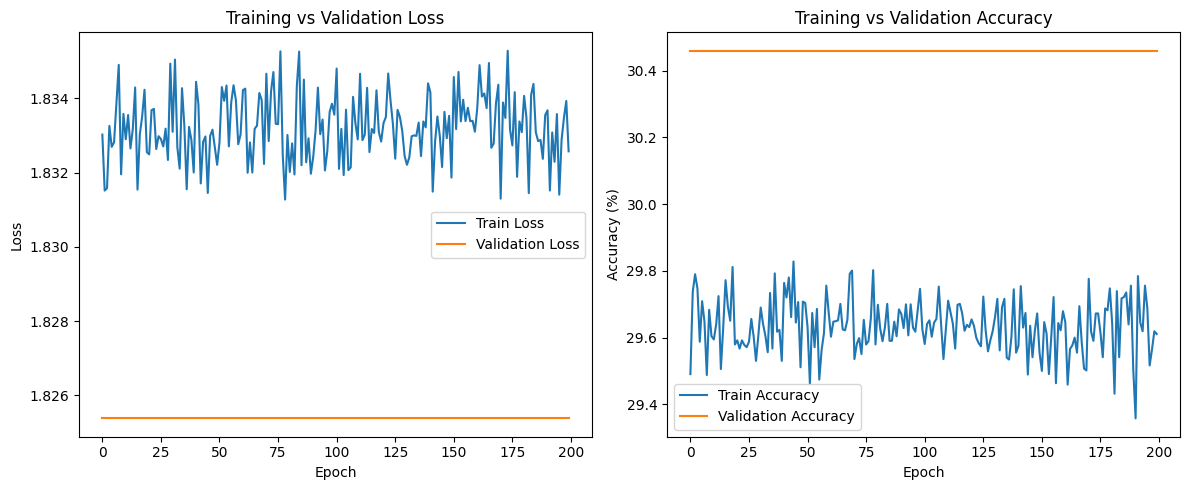

The system was trained for batch size of :  200
Epoch [1/200] | Train Loss: 1.8336 | Train Accuracy: 29.54% | Val Loss: 1.8254 | Val Accuracy: 30.46%
Epoch [2/200] | Train Loss: 1.8334 | Train Accuracy: 29.61% | Val Loss: 1.8254 | Val Accuracy: 30.46%
Epoch [3/200] | Train Loss: 1.8313 | Train Accuracy: 29.62% | Val Loss: 1.8254 | Val Accuracy: 30.46%
Epoch [4/200] | Train Loss: 1.8325 | Train Accuracy: 29.57% | Val Loss: 1.8254 | Val Accuracy: 30.46%
Epoch [5/200] | Train Loss: 1.8341 | Train Accuracy: 29.64% | Val Loss: 1.8254 | Val Accuracy: 30.46%
Epoch [6/200] | Train Loss: 1.8343 | Train Accuracy: 29.77% | Val Loss: 1.8254 | Val Accuracy: 30.46%
Epoch [7/200] | Train Loss: 1.8336 | Train Accuracy: 29.52% | Val Loss: 1.8254 | Val Accuracy: 30.46%
Epoch [8/200] | Train Loss: 1.8332 | Train Accuracy: 29.75% | Val Loss: 1.8254 | Val Accuracy: 30.46%
Epoch [9/200] | Train Loss: 1.8333 | Train Accuracy: 29.66% | Val Loss: 1.8254 | Val Accuracy: 30.46%
Epoch [10/200] | Train Loss: 1.834

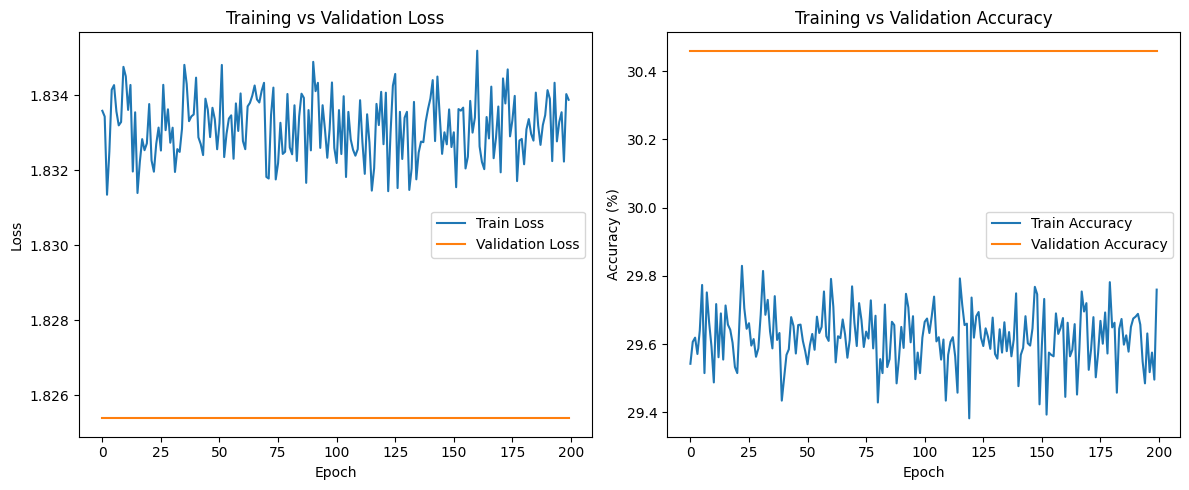

The system was trained for batch size of :  250
Epoch [1/200] | Train Loss: 1.8344 | Train Accuracy: 29.60% | Val Loss: 1.8254 | Val Accuracy: 30.46%
Epoch [2/200] | Train Loss: 1.8341 | Train Accuracy: 29.71% | Val Loss: 1.8254 | Val Accuracy: 30.46%
Epoch [3/200] | Train Loss: 1.8340 | Train Accuracy: 29.64% | Val Loss: 1.8254 | Val Accuracy: 30.46%
Epoch [4/200] | Train Loss: 1.8327 | Train Accuracy: 29.61% | Val Loss: 1.8254 | Val Accuracy: 30.46%
Epoch [5/200] | Train Loss: 1.8336 | Train Accuracy: 29.56% | Val Loss: 1.8254 | Val Accuracy: 30.46%
Epoch [6/200] | Train Loss: 1.8338 | Train Accuracy: 29.79% | Val Loss: 1.8254 | Val Accuracy: 30.46%
Epoch [7/200] | Train Loss: 1.8330 | Train Accuracy: 29.72% | Val Loss: 1.8254 | Val Accuracy: 30.46%
Epoch [8/200] | Train Loss: 1.8345 | Train Accuracy: 29.48% | Val Loss: 1.8254 | Val Accuracy: 30.46%
Epoch [9/200] | Train Loss: 1.8321 | Train Accuracy: 29.79% | Val Loss: 1.8254 | Val Accuracy: 30.46%
Epoch [10/200] | Train Loss: 1.834

In [ ]:
epochs = 200

best_value_accuracy = 0
for batch_size in range(50,300,50):

    print("The system was trained for batch size of : ",batch_size)

    train_loader = DataLoader(
        train_dataset.dataset,
        batch_size=batch_size,
        sampler=sampler
    )

    train_validation_losses = {
        "train_loss" : [],
        "validation_loss" : []
    }
    train_validation_accuracies = {
        "train_accuracies" : [],
        "validation_accuracies" : []
    }

    trainTheModel()

    # 12. Plot graphs
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(train_validation_losses["train_loss"], label="Train Loss")
    plt.plot(train_validation_losses["validation_loss"], label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training vs Validation Loss")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(train_validation_accuracies["train_accuracies"], label="Train Accuracy")
    plt.plot(train_validation_accuracies["validation_accuracies"], label="Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy (%)")
    plt.title("Training vs Validation Accuracy")
    plt.legend()

    plt.tight_layout()
    plt.show()

Accuracy: 0.2982
F1 Score: 0.14663979469368368

Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00       103
           1       0.28      0.06      0.09       600
           2       0.00      0.00      0.00       525
           3       0.30      0.99      0.46      1475
           4       0.00      0.00      0.00      1110
           5       0.00      0.00      0.00       619
           6       0.00      0.00      0.00       359
           7       0.00      0.00      0.00       160
           8       0.00      0.00      0.00        49

    accuracy                           0.30      5000
   macro avg       0.06      0.12      0.06      5000
weighted avg       0.12      0.30      0.15      5000



d:\IJSE CAME\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\IJSE CAME\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\IJSE CAME\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


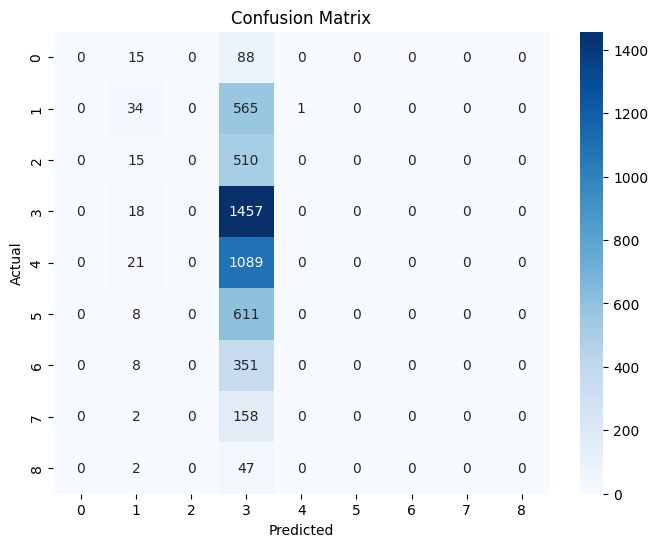


 FAIRNESS ANALYSIS 

AGE ACCURACY
Age 0: 0.000
Age 1: 0.057
Age 2: 0.000
Age 3: 0.988
Age 4: 0.000
Age 5: 0.000
Age 6: 0.000
Age 7: 0.000
Age 8: 0.000

RACE ACCURACY
White: 0.394
Black: 0.243
Latino_Hispanic: 0.268
East Asian: 0.297
Southeast Asian: 0.227
Indian: 0.301
Middle Eastern: 0.337

GENDER ACCURACY
Male: 0.252
Female: 0.354


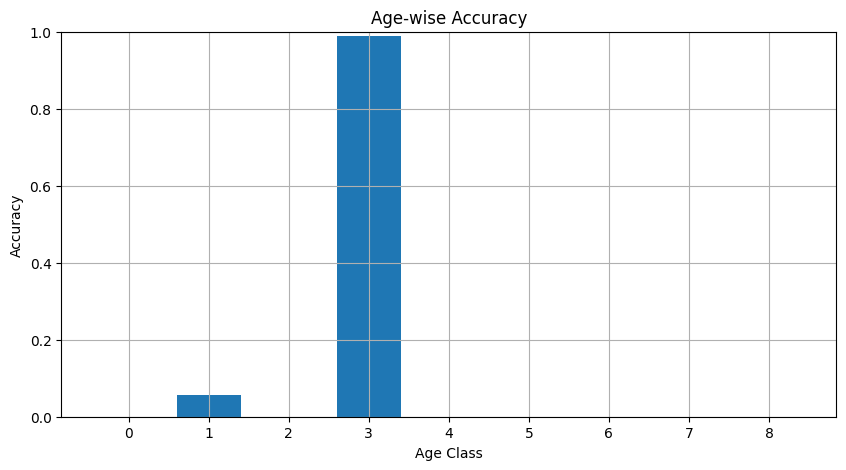

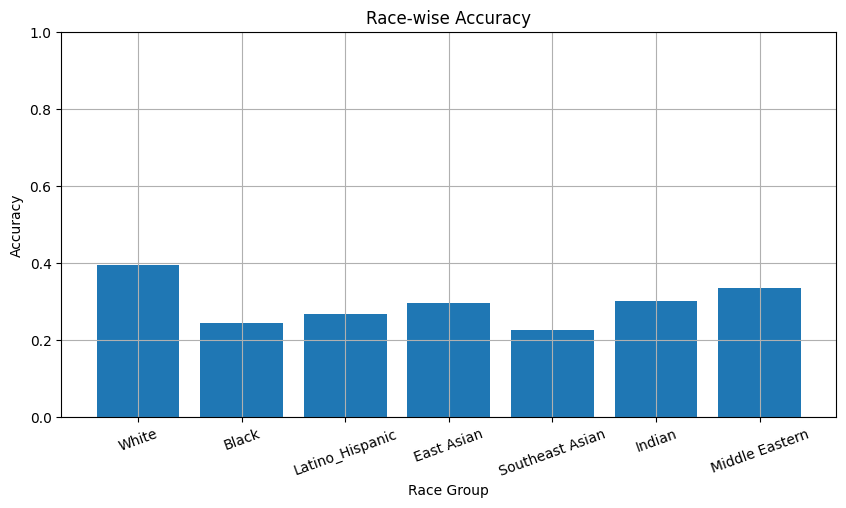

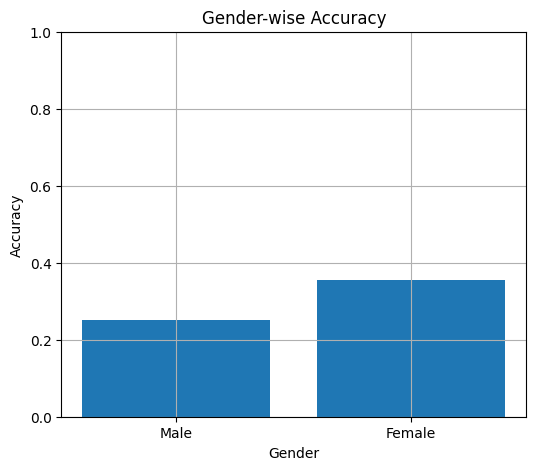


FAIRNESS GAPS
Race Gap   : 0.167
Gender Gap : 0.102
Age Gap    : 0.988


In [ ]:
model = CNN(num_classes).to(device)
checkpoint = torch.load(
    CHECK_POINT_PATH,
    map_location=device
)
model.load_state_dict(checkpoint["model_state_dict"])

acc, f1, cm, report = full_evaluate(model, val_dataset)
print("Accuracy:", acc)
print("F1 Score:", f1)
print("\nClassification Report:\n", report)

import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()
fairness = classWiseEvaluation(model, val_dataset, device)
race_acc = fairness["race_acc"]
gender_acc = fairness["gender_acc"]
age_acc = fairness["age_acc"]